# Avaliação 1 — Métodos e Técnicas de Pesquisa Quantitativa

**Aluno(a):** _(escreva seu nome aqui)_
**Curso:** Administração — UFMA
**Data:** ____ / ____ / 2026

---

## Instruções

1. A avaliação é **inteiramente neste notebook**. Não há prova em papel.
2. Ela tem **três partes**: a **A** (conceitual), a **B** (prática) e o **Projeto**.
3. A Parte A é feita **sem consulta e com as telas fechadas**. As Partes B e o Projeto
   admitem consulta.
4. Responda **nas células indicadas**, que já vêm com as linhas `---`. Não apague os
   enunciados, e não crie células novas.
5. Salve com as saídas visíveis: rode *Runtime → Run all* antes de entregar.
6. Compartilhe o link do notebook com o professor ao final.

> **Sobre o uso de IA.** O assistente é **permitido** nas Partes B e no Projeto, e
> **proibido** na Parte A. Quem usar, registra o pedido, a checagem e o que mudou, na
> célula de registro. O registro não desconta pontos; a omissão é falta de honestidade
> acadêmica.

---

## Parte A — conceitual (30 minutos, sem consulta)

Responda em **duas ou três frases** cada. O que se avalia é a **justificativa**, e não a
fórmula. Não há conta a fazer.

### **A1.** Uma variável registra o **nível de satisfação do cliente**, em uma escala de 0 a 10. Em que nível de mensuração ela está? **O que isso permite** calcular, e o que **não** permite?

_(responda aqui, em duas ou três frases)_

---


### **A2.** Aplique o **teste do zero** à variável **“número de funcionários de uma empresa”** e diga em que nível ela está.

_(responda aqui, em duas ou três frases)_

---


### **A3.** Você tem a **receita anual** de 451 companhias abertas e precisa escolher **uma** medida para representar o conjunto. Qual você escolhe, e por quê?

_(responda aqui, em duas ou três frases)_

---


### **A4.** Por que **somar os desvios** de cada valor em relação à média **não** serve como medida de dispersão? E por que, então, se eleva ao quadrado?

_(responda aqui, em duas ou três frases)_

---


### **A5.** Você precisa comparar a **dispersão do preço da gasolina**, medido em R$ por litro, com a **dispersão do IPCA**, medido em pontos percentuais. Que medida você usa, e por quê?

_(responda aqui, em duas ou três frases)_

---


### **A6.** A média de uma variável é R$ 6,13 e a mediana é R$ 6,08. **O que essa diferença sugere** sobre a forma da distribuição — e o que ela **não** permite concluir?

_(responda aqui, em duas ou três frases)_

---


### **A7.** Uma empresa diz: *“a inadimplência média do período foi de 3,54%, e o valor de hoje é 3,54%”*. O que está errado nessa afirmação?

_(responda aqui, em duas ou três frases)_

---


## Parte B — prática (120 minutos, com consulta)

A base é o **cadastro de companhias abertas com demonstrações financeiras de 2024**
(CVM) — 451 companhias, com receita, lucro líquido e setor.

A célula abaixo carrega a base. **Execute-a.**

> **A base está no arquivo local**, e não em uma API: assim ela nunca falha durante a
> avaliação. Se a célula der erro, chame o professor.

In [1]:
# CÉLULA B0: carga da base. Já vem pronta — execute.
import pandas as pd

URL = ("https://raw.githubusercontent.com/tadeugomes/"
       "metodos-pesquisa-quantitativa/main/dados/cvm_dre_2024.csv")

try:
    base = pd.read_csv(URL)
except Exception:
    # contingência: só se a internet falhar. Nesse caso, faça upload do arquivo
    # dados/cvm_dre_2024.csv para o Colab e execute esta célula de novo.
    base = pd.read_csv("cvm_dre_2024.csv")

print(f"Base carregada: {len(base)} companhias abertas, {base['setor'].nunique()} setores")
print("colunas:", list(base.columns))
base.head(3)

Base carregada: 451 companhias abertas, 47 setores
colunas: ['CD_CVM', 'DENOM_CIA', 'receita', 'ESCALA_MOEDA', 'lucro_liquido', 'setor']


,CD_CVM,DENOM_CIA,receita,ESCALA_MOEDA,lucro_liquido,setor
0,1023,BCO BRASIL S.A.,273505274.0,MIL,29171564.0,Bancos
1,14206,BRB BANCO DE BRASILIA S.A.,8909356.0,MIL,311019.0,Bancos
2,2437,AXIA ENERGIA S.A.,40181552.0,MIL,10380753.0,Emp. Adm. Part. - Energia Elétrica


### B1. A tabela de frequências, e a leitura

Monte a tabela de frequências do **setor** e escreva, embaixo, a **frase de leitura** do
setor mais frequente: **o percentual, a contagem entre parênteses e o total declarado**.

In [2]:
# CÉLULA B1: a tabela de frequências do setor.
freq = base["setor"].value_counts()
tabela_setor = (freq.rename_axis("setor").reset_index(name="companhias"))
tabela_setor["pct"] = (tabela_setor["companhias"] / len(base) * 100).round(1)
n_total = len(base)
tabela_setor.head(5)

,setor,companhias,pct
0,"Construção Civil, Mat. Constr. e Decoração",42,9.3
1,Comércio (Atacado e Varejo),39,8.6
2,Energia Elétrica,30,6.7
3,Serviços Transporte e Logística,27,6.0
4,"Máquinas, Equipamentos, Veículos e Peças",21,4.7


_(escreva aqui a frase de leitura do setor mais frequente)_

---


### B2. A medida de posição, e a justificativa

A variável `receita` está em milhares de reais. Calcule **as três medidas de posição** e
decida **qual delas** descreve melhor o conjunto. **Justifique com os números.**

In [3]:
# CÉLULA B2: as três medidas de posição da receita.
receita = base["receita"].dropna()
print(f"n = {len(receita)}")
print(f"média   = {receita.mean():,.0f} milhares de reais".replace(",", "."))
print(f"mediana = {receita.median():,.0f} milhares de reais".replace(",", "."))
print(f"razão média/mediana = {receita.mean() / receita.median():.1f} vezes")

n = 451
média   = 21.154.317 milhares de reais
mediana = 2.171.344 milhares de reais
razão média/mediana = 9.7 vezes


_(qual medida você escolhe, e por quê? cite os números)_

---



### B3. A dispersão

Calcule o **desvio padrão**, o **coeficiente de variação** e o **IQR** da receita.
Depois, escreva **uma frase** que diga o que esses números mostram.

In [4]:
# CÉLULA B3: a dispersão da receita.
desvio = receita.std()
cv = desvio / receita.mean() * 100
q1, q3 = receita.quantile(0.25), receita.quantile(0.75)
print(f"desvio padrão = {desvio:,.0f}".replace(",", "."))
print(f"coeficiente de variação = {cv:.2f}%")
print(f"IQR = {q3 - q1:,.0f}   (Q1 {q1:,.0f} | Q3 {q3:,.0f})".replace(",", "."))
print()
print("O CV acima de 100% é o sinal numérico da assimetria:")
print("o desvio é maior que a própria média.")
print()
print("Conferência (o valor esperado está no gabarito do professor):")

desvio padrão = 134.023.175
coeficiente de variação = 633.55%
IQR = 7.436.834   (Q1 614.907 | Q3 8.051.740)

O CV acima de 100% é o sinal numérico da assimetria:
o desvio é maior que a própria média.

Conferência (o valor esperado está no gabarito do professor):


_(escreva aqui a frase sobre a dispersão)_

---


### B4. A forma da distribuição

Faça o **histograma** da receita e descreva a forma em **uma frase, podendo usar
números**.

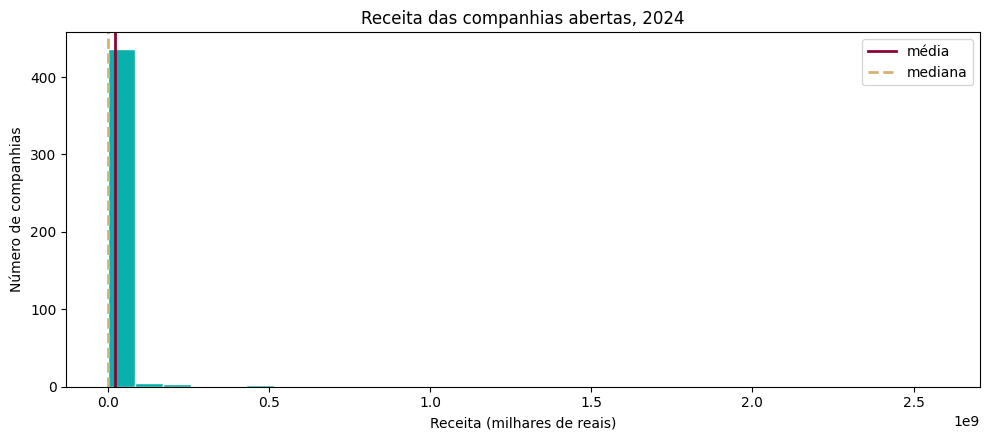

assimetria calculada: 16.14


In [5]:
# CÉLULA B4: o histograma da receita.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(receita, bins=30, color="#0AB0AB", edgecolor="white")
ax.axvline(receita.mean(), color="#8D0333", linewidth=2, label="média")
ax.axvline(receita.median(), color="#D4B277", linewidth=2, linestyle="--", label="mediana")
ax.set_xlabel("Receita (milhares de reais)")
ax.set_ylabel("Número de companhias")
ax.set_title("Receita das companhias abertas, 2024")
ax.legend()
plt.tight_layout()
plt.show()

print(f"assimetria calculada: {receita.skew():.2f}")

_(descreva a forma em uma frase)_

---


### B5. A conclusão

Você tem uma companhia com receita de **R$ 2 milhões** (2.000.000 em milhares). Ela
está **acima** ou **abaixo** do típico? Que medida responde a essa pergunta, e por quê?

In [6]:
# CÉLULA B5: onde R$ 2 milhões cai na distribuição.
alvo = 2_000_000
abaixo = (receita < alvo).mean() * 100
print(f"receita de R$ 2 milhões: {abaixo:.1f}% das companhias faturam menos que isso")
print(f"mediana = {receita.median():,.0f}".replace(",", "."))
print(f"média   = {receita.mean():,.0f}".replace(",", "."))
print()
print("A medida que responde é a MEDIANA: ela divide o conjunto ao meio.")

receita de R$ 2 milhões: 47.7% das companhias faturam menos que isso
mediana = 2.171.344
média   = 21.154.317

A medida que responde é a MEDIANA: ela divide o conjunto ao meio.


_(responda aqui: acima ou abaixo, e com que medida)_

---


## Registro de uso de IA

**Obrigatório para quem usou o assistente** nas Partes B ou no Projeto. Preencha a
tabela, ou escreva “não usei”. O registro não desconta pontos.

| O que eu pedi | O que eu conferi | O que eu mudei |
|---|---|---|
| | | |
| | | |

---


## Projeto — 1ª entrega (30 minutos)

Preencha os três itens e **verifique que a base carrega sem erro**.

**1. Tema e pergunta de pesquisa**

---


**2. A base escolhida, e a célula que a carrega**

_(cole abaixo o código que carrega a sua base, e execute-o)_


In [7]:
# A célula que carrega a base do MEU projeto.
# Substitua o endereço pelo da sua fonte, ajuste a codificação e o separador,
# e execute. O objetivo é que a base carregue SEM ERRO.

import pandas as pd

url = "COLE AQUI O ENDEREÇO DA SUA FONTE"
# exemplo, se a sua base for um CSV aberto:
# minha_base = pd.read_csv(url, sep=";", encoding="utf-8-sig", decimal=",")

# print(minha_base.shape)
# minha_base.head()

**3. Os seis critérios da sua fonte**

| # | Critério | A sua fonte |
|---|---|---|
| 1 | Periodicidade | |
| 2 | Granularidade | |
| 3 | Cobertura | |
| 4 | Metadado | |
| 5 | Licença e citação | |
| 6 | Acesso | |

---

**Antes de entregar:** rode *Runtime → Run all*, confirme que a Parte A está respondida
nas células de texto, e compartilhe o link com o professor.

---

> **Este notebook é o primeiro capítulo do seu relatório final.** Guarde-o.